In [3]:
#TESTING THAT DFT WORKS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [4]:

def DFT(f):
    Nx = f.shape[0]
    F = np.zeros((Nx), dtype=complex)
    for k1 in range(Nx):
        for x in range(Nx): 
                F[k1]+= f[x] * np.exp(-2j * np.pi * (k1 * x / Nx))
    return F

def IDFT(F):
    Nx = F.shape[0]
    f = np.zeros((Nx), dtype=complex)
    for x in range(Nx):
        for k1 in range(Nx):
            f[x] += F[k1] * np.exp(2j * np.pi * (k1 * x / Nx ))
    return np.real( f / (Nx) )


def IDFT_invert_laplacian(F):
    Nx = F.shape[0]
    f = np.zeros((Nx), dtype=complex)
    for x in range(Nx): 
        for k1 in range(Nx):
            K=((2*np.pi)**2)*((k1**2)/(Nx**2))
            if K==0: K=1e-10
            f[x] += F[k1]/(-K) * np.exp(2j * np.pi * (k1 * x / Nx ))
    return np.real( f / (Nx) )


def compute_laplacian(field, dx):
    # Pad the field to handle boundaries (Neumann condition: zero-gradient)
    padded = np.pad(field, pad_width=1, mode='edge')
    
    # Compute second derivatives
    d2f_dx2 = (padded[2:] - 2 * padded[1:-1] + padded[:-2]) / dx**2
    # d2f_dy2 = (padded[1:-1, 2:] - 2 * padded[1:-1, 1:-1] + padded[1:-1, :-2]) / dy**2
    
    # Laplacian as the sum of second derivatives
    laplacian = d2f_dx2 #+ d2f_dy2
    
    return laplacian

In [8]:
# fig=plt.figure(figsize=(14*1.5,6))
# gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
# ax0=fig.add_subplot(gs[0,0])
# ax1=fig.add_subplot(gs[0,1])
# ax2=fig.add_subplot(gs[0,2])
# ax3=fig.add_subplot(gs[0,3])


# #TESTING LAPLACIAN INVERT FUNCTION
# Nx = 50
# dx=1

# # Create a 2D grid for the domain
# # x = np.linspace(0, 1, Nx)
# x = np.linspace(0, Nx-1, Nx)

# ####################
# # Create the RHS array (zero everywhere)
# RHS = np.zeros((Nx))
# RHS[Nx//2]=1e32#1e32

# contour0=ax0.plot(RHS)
# ax0.set_ylabel('value');ax0.set_xlabel('x')
# ax0.set_title(f"RHS. {RHS[Nx//2]} at center.")
# ####################

# #####################
# RHS_fft=DFT(RHS)
# contour1=ax1.plot(RHS_fft)
# ax1.set_title(f"fft of RHS")

# LHS=IDFT_invert_laplacian(RHS_fft)
# contour1=ax2.plot(LHS)
# ax2.set_title(f"solution for f")
# ####################

# # ##############################################################################################################################

# ####################
# #TESTING if taking laplacian gives all 1s
# out=LHS
# laplacian_out=compute_laplacian(out, dx)
# # laplacian_out=LHS;laplacian_out[laplacian_out<1e-12]=0 #TESTING

# contour2=ax3.plot(laplacian_out) #NOT WORKING CURRENTLY 
# ax3.set_title(f"Uninverting. {laplacian_out[Nx//2]*1e2/RHS[Nx//2]:.3f}% of {RHS[Nx//2]} at center.")
# # fig.colorbar(contour2,ax=ax2) 

# ####################
# fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 1D array with Nx = 50, dx = 1")
# ax0.set_ylim(top=1.1e32)
# ax3.set_ylim(top=1.1e32)

(-0.05345878601074219, 1.1)

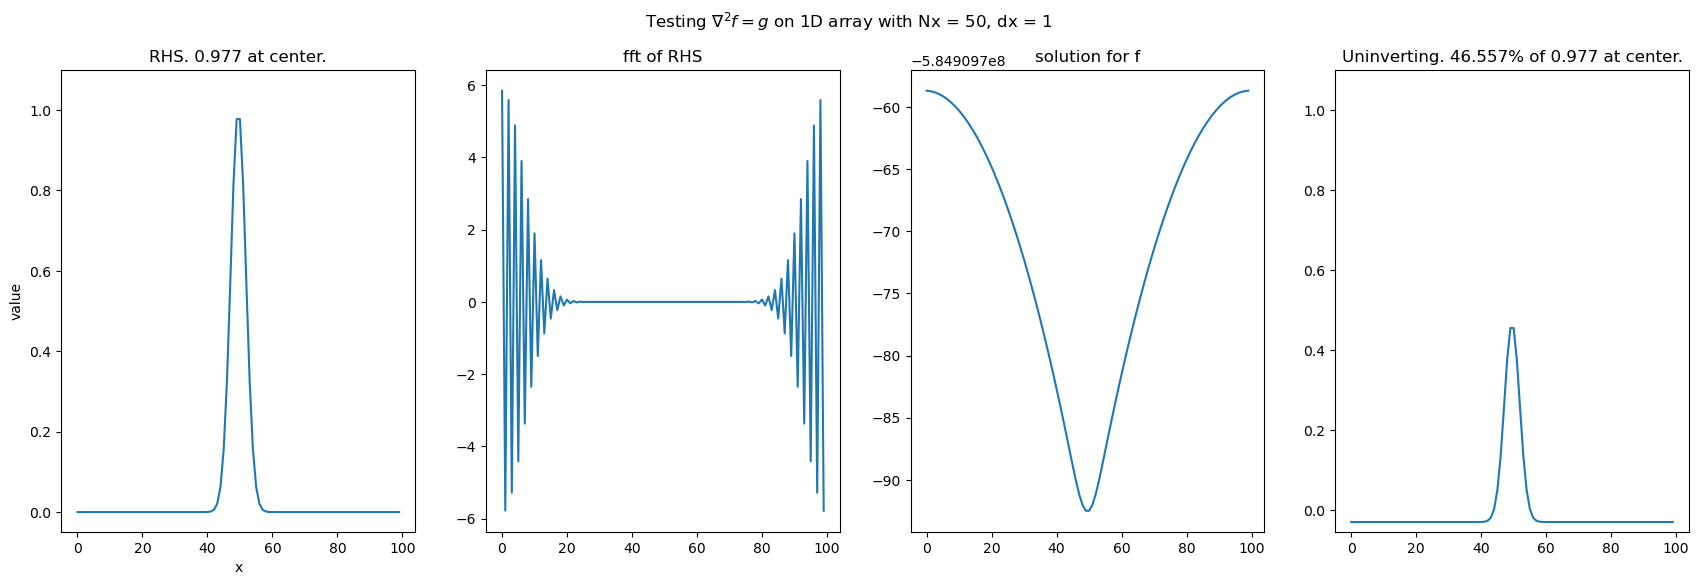

In [11]:
fig=plt.figure(figsize=(14*1.5,6))
gs=gridspec.GridSpec(nrows=1,ncols=4,figure=fig)
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
ax2=fig.add_subplot(gs[0,2])
ax3=fig.add_subplot(gs[0,3])


#TESTING LAPLACIAN INVERT FUNCTION
Nx = 100
dx=1

# Create a 2D grid for the domain
# x = np.linspace(0, 1, Nx)
x = np.linspace(0, Nx-1, Nx)

####################
# Create the RHS array (zero everywhere)
RHS = np.zeros((Nx))
RHS[Nx//2]=1e32#1e32

domain = np.linspace(-15, 15, Nx) # Generate evenly spaced points between -3 and 3
a=1; gauss =np.exp(-a*domain**2 )
RHS=gauss

contour0=ax0.plot(RHS)
ax0.set_ylabel('value');ax0.set_xlabel('x')
ax0.set_title(f"RHS. {RHS[Nx//2]:.3f} at center.")
####################

#####################
RHS_fft=DFT(RHS)
contour1=ax1.plot(RHS_fft)
ax1.set_title(f"fft of RHS")

LHS=IDFT_invert_laplacian(RHS_fft)
contour1=ax2.plot(LHS)
ax2.set_title(f"solution for f")
####################

# ##############################################################################################################################

####################
#TESTING if taking laplacian gives all 1s
out=LHS
laplacian_out=compute_laplacian(out, dx)
# laplacian_out=LHS;laplacian_out[laplacian_out<1e-12]=0 #TESTING

contour2=ax3.plot(laplacian_out) #NOT WORKING CURRENTLY 
ax3.set_title(f"Uninverting. {laplacian_out[Nx//2]*1e2/RHS[Nx//2]:.3f}% of {RHS[Nx//2]:.3f} at center.")
# fig.colorbar(contour2,ax=ax2) 

####################
fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" on 1D array with Nx = 50, dx = 1")
ax0.set_ylim(top=1.1)
ax3.set_ylim(top=1.1)

In [7]:

# def DFT(f):
#     Nx, Ny = f.shape
#     F = np.zeros((Nx, Ny), dtype=complex)
#     for k1 in range(Nx):
#         for k2 in range(Ny):
#             for x in range(Nx): 
#                 for y in range(Ny): 
#                     F[k1, k2] += f[x, y] * np.exp(-2j * np.pi * (k1 * x / Nx + k2 * y / Ny))
#     return F

# def IDFT(F):
#     Nx, Ny = F.shape
#     f = np.zeros((Nx, Ny), dtype=complex)
#     for x in range(Nx):
#         for y in range(Ny):
#             for k1 in range(Nx):
#                 for k2 in range(Ny):
#                     f[x, y] += F[k1, k2] * np.exp(2j * np.pi * (k1 * x / Nx + k2 * y / Ny))
#     return np.real( f / (Nx * Ny) )


# def IDFT_invert_laplacian(F):
#     Nx, Ny = F.shape
#     f = np.zeros((Nx, Ny), dtype=complex)
#     for x in range(Nx): 
#         for y in range(Ny): 
#             for k1 in range(1,Nx):
#                 for k2 in range(1,Ny):
#                     K=((2*np.pi)**2)*((k1**2)/(Nx**2)+(k2**2)/(Ny**2))
#                     f[x, y] += F[k1, k2]/(-K) * np.exp(2j * np.pi * (k1 * x / Nx + k2 * y / Ny))
#     return np.real( f / (Nx * Ny) )


# def compute_laplacian(field, dx, dy):
#     # Pad the field to handle boundaries (Neumann condition: zero-gradient)
#     # padded = np.pad(field, pad_width=((0, 0), (1, 1)), mode='wrap')  # Periodic padding in y-direction
#     # padded = np.pad(padded, pad_width=((1, 1), (0, 0)), mode='edge')  # Edge (Ghost Cell) padding in x-direction
#     padded = np.pad(field, pad_width=1, mode='edge') 
    
#     # Compute second derivatives
#     d2f_dx2 = (padded[2:, 1:-1] - 2 * padded[1:-1, 1:-1] + padded[:-2, 1:-1]) / dx**2
#     d2f_dy2 = (padded[1:-1, 2:] - 2 * padded[1:-1, 1:-1] + padded[1:-1, :-2]) / dy**2
    
#     # Laplacian as the sum of second derivativess
#     laplacian = d2f_dx2 + d2f_dy2
    
#     return laplacian


In [6]:
# fig=plt.figure(figsize=(14*1.5,6))
# gs=gridspec.GridSpec(nrows=1,ncols=3,figure=fig)
# ax0=fig.add_subplot(gs[0,0])
# ax1=fig.add_subplot(gs[0,1])
# ax2=fig.add_subplot(gs[0,2])


# #TESTING LAPLACIAN INVERT FUNCTION
# Nx = 10
# Ny = 10
# dx=1;dy=1

# # Create a 2D grid for the domain
# x = np.linspace(0, 1, Nx)
# y = np.linspace(0, 1, Ny)

# ####################
# # Create the RHS array (zero everywhere)
# RHS = np.zeros((Nx, Ny))
# RHS[Nx//2,Ny//2]=1e2#1e34 #*****

# contour0=ax0.contourf(RHS)
# ax0.set_title(f"RHS. {RHS[Nx//2,Ny//2]} at center.")
# fig.colorbar(contour0,ax=ax0)
# ####################

# ####################
# LHS=DFT(RHS)
# # LHS=IDFT(LHS);LHS[LHS<1e-12]=0 #TESTING
# LHS=IDFT_invert_laplacian(LHS)
# contour1=ax1.contourf(LHS)
# ax1.set_title(f"solution for f")
# fig.colorbar(contour1,ax=ax1) 
# ####################


# ##############################################################################################################################

# ####################
# #TESTING if taking laplacian gives all 1s
# out=LHS
# laplacian_out=compute_laplacian(out, dx, dy)
# # laplacian_out=LHS;laplacian_out[laplacian_out<1e-12]=0 #TESTING

# contour2=ax2.contourf(laplacian_out) #NOT WORKING CURRENTLY 
# ax2.set_title(f"Checking RHS. {laplacian_out[Nx//2,Ny//2]*1e2/RHS[Nx//2,Ny//2]:.3f}% of {RHS[Nx//2, Ny//2]} at center.")
# fig.colorbar(contour2,ax=ax2) 

# ####################
# fig.suptitle(f"Testing " + r'$\nabla^2 f = g$' + f" with {RHS[Nx//2, Ny//2]} at the center of g domain, 0 elsewhere")
# ax0.scatter(Nx//2,Ny//2,color='red',s=2,label='center')
# ax1.scatter(Nx//2,Ny//2,color='red',s=2)
# ax2.scatter(Nx//2,Ny//2,color='red',s=2)
# fig.legend()

# # plt.contourf(laplacian_out[48:52,48:52]);
# # plt.colorbar()
# # plt.title('zoomed in ')
# # plt.scatter(2,2,color='red')